Поскольку простые задания - это неинтересно, в качестве сайта для парсинга был выбран небезызвестный Авито. После нескольких дней борьбы с блокировкой IP и капчей мне таки удалось собрать объявления о продаже недвижимости в Москве. Однако Jupiter не поддерживает в полной мере асинхонные функции и парсер пришлось запускать в виде отдельного Python файла. Тем не менее в следующей ячейке приведен рабочий код.

import asyncio
from playwright.async_api import async_playwright, TimeoutError
import time
import random
import json
from urllib.parse import urljoin
import re

# Список актуальных User-Agent (Windows, macOS, Chrome, Firefox, Safari)
USER_AGENTS = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/128.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 14.6; rv:129.0) Gecko/20100101 Firefox/129.0",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:129.0) Gecko/20100101 Firefox/129.0",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 15_0) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/18.0 Safari/605.1.15",
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/128.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Edge/128.0.0.0",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 14_6_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/128.0.0.0 Safari/537.36"
]


async def parse_avito_page(page_url: str, page_num: int, max_retries: int = 10) -> list:
    """
    Парсит ссылки на объявления с указанной страницы Авито.
    Браузер запускается один раз, при ошибках — перезагрузка страницы с паузами.
    
    Args:
        page_url: базовый URL страницы поиска (без номера страницы)
        page_num: номер страницы
        max_retries: максимальное число попыток загрузки страницы
    Returns:
        Список ссылок на объявления
    """
    links = []
    full_url = f"{page_url}&p={page_num}"
    
    try:
        async with async_playwright() as playwright:
            browser = await playwright.chromium.launch(headless=False)
            context = await browser.new_context(
                viewport={"width": 1920, "height": 1080},
                user_agent=random.choice(USER_AGENTS)
            )
            page = await context.new_page()

            for attempt in range(1, max_retries + 1):
                try:
                    print(f"[Playwright] Загрузка страницы {page_num} (попытка {attempt}/{max_retries}): {full_url}")

                    response = await page.goto(
                        full_url,
                        wait_until="commit",
                        timeout=30000
                    )

                    # Проверка HTTP-статуса
                    if response.status == 200:
                        print(f"Страница {page_num} загружена успешно (статус 200)")
                        break  # Успех — выходим из цикла попыток
                    elif response.status == 429:
                        if attempt < max_retries:
                            sleep_time = 10
                            print(f"[429] Слишком много запросов. Пауза {sleep_time} сек перед повторной попыткой...")
                            await asyncio.sleep(sleep_time)
                            continue  # Повторить попытку
                        else:
                            print("[429] Все попытки исчерпаны.")
                            await asyncio.sleep(30)

                    else:
                        print(f"[HTTP {response.status}] Неудачный статус для страницы {page_num}. Попытка {attempt}")
                        if attempt < max_retries:
                            sleep_time = random.uniform(5, 10)
                            await asyncio.sleep(sleep_time)
                            continue
                        else:
                            return []

                except TimeoutError:
                    print(f"[TIMEOUT] Таймаут загрузки страницы {page_num}. Попытка {attempt}")
                    if attempt < max_retries:
                        sleep_time = random.uniform(5, 10)
                        await asyncio.sleep(sleep_time)
                        continue
                    else:
                        return []
                except Exception as e:
                    print(f"[ERROR] Исключение при загрузке страницы {page_num}: {e}. Попытка {attempt}")
                    if attempt < max_retries:
                        sleep_time = random.uniform(5, 10)
                        await asyncio.sleep(sleep_time)
                        continue
                    else:
                        return []

            # Если дошли сюда — страница загружена с кодом 200
            try:
                await page.wait_for_selector('div[data-marker="item"]', timeout=10000)
            except TimeoutError:
                print(f"На странице {page_num} нет объявлений (селектор не найден)")
                return []

            # Скролл для подгрузки всех объявлений
            await simulate_human_behavior(page)
            await page.wait_for_timeout(3000)  # Дать время на загрузку

            # Сбор ссылок
            items = await page.query_selector_all('a[data-marker="item-title"]')
            for item in items:
                href = await item.get_attribute("href")
                if href:
                    if href.startswith('http'):
                        full_link = href
                    else:
                        full_link = f"https://www.avito.ru/{href.lstrip('/')}"
                    links.append(full_link)

            await context.close()
            await browser.close()

    except Exception as e:
        print(f"[CRITICAL] Непредвиденная ошибка при парсинге страницы {page_num}: {e}")

    return links

def extract_digits(price_str: str) -> str:
    """
    Извлекает из строки все цифры, склеивает их в одну последовательность.
    """
    digits = re.sub(r'\D', '', price_str)  # \D — любой нецифровой символ
    return digits

async def parse_ad_page(page, ad_url: str, max_retries: int = 3, backoff_factor: int = 2) -> dict:
    """
    Парсит цену и описание с страницы объявления.
    Использует переданную вкладку `page`, не создаёт браузер.
    При 429 перезагружает страницу с паузами.
    """
    for attempt in range(max_retries + 1):
        try:
            print(f"[Playwright] Парсинг объявления: {ad_url} (попытка {attempt + 1})")

            # Переходим на URL
            response = await page.goto(
                ad_url,
                wait_until="domcontentloaded",
                timeout=30000
            )

            # Проверка статуса
            if response.status == 200:
                print(f"Успешно загружено: {ad_url}")
            elif response.status == 429:
                if attempt < max_retries:
                    sleep_time = backoff_factor * (2 ** attempt)
                    print(f"[429] Пауза {sleep_time} сек перед повторной попыткой...")
                    await asyncio.sleep(sleep_time)
                    continue  # перезагрузка цикла → новый goto
                else:
                    print("[429] Все попытки исчерпаны.")
                    return {
                        "url": ad_url,
                        "price": "429_max_retries",
                        "description": ""
                    }
            else:
                print(f"[HTTP {response.status}] Ошибка для {ad_url}")
                if attempt < max_retries:
                    await asyncio.sleep(random.uniform(5, 10))
                    continue
                else:
                    return {"url": ad_url, "price": f"http_{response.status}", "description": ""}

            # Имитация человека
            await simulate_human_behavior(page)

            # Извлечение цены
            price_element = await page.query_selector('span[itemprop="price"]')
            if not price_element:
                price_element = await page.query_selector('span[data-marker="price/value"]')

            raw_price = (
                await price_element.inner_text()
                if (price_element and await price_element.is_visible())
                else "0"
            )
            price = extract_digits(raw_price) or "0"

            # Извлечение описания
            try:
                await page.wait_for_selector('div[data-marker="item-view/item-description"]', timeout=5000)
                desc_element = await page.query_selector('div[data-marker="item-view/item-description"]')
                description = (
                    await desc_element.inner_text()
                    if (desc_element and await desc_element.is_visible())
                    else ""
                )
            except TimeoutError:
                description = ""

            return {
                "url": ad_url,
                "price": price.strip(),
                "description": description.strip()
            }

        except TimeoutError:
            print(f"[TIMEOUT] Таймаут при загрузке {ad_url} (попытка {attempt + 1})")
            if attempt < max_retries:
                await asyncio.sleep(random.uniform(5, 10))
                continue
            else:
                return {"url": ad_url, "price": "timeout", "description": ""}

        except Exception as e:
            print(f"[ERROR] Ошибка при парсинге {ad_url}: {e} (попытка {attempt + 1})")
            if attempt < max_retries:
                await asyncio.sleep(random.uniform(5, 10))
                continue
            else:
                return {"url": ad_url, "price": "parse_error", "description": ""}

    return {"url": ad_url, "price": "max_retries_exceeded", "description": ""}


async def simulate_human_behavior(page):
    await page.evaluate("window.scrollBy(0, window.innerHeight / 2)")
    await page.wait_for_timeout(random.randint(1000, 2000))
    await page.mouse.move(100, 100)
    await page.mouse.move(200, 200)
    await page.evaluate("window.scrollTo(0, document.body.scrollHeight)")
    await page.wait_for_timeout(random.randint(1500, 2500))

async def main():
    base_url = "https://www.avito.ru/moskva/kvartiry/prodam/vtorichka-ASgBAgICAkSSA8YQ5geMUg?localPriority=0"
    all_ads = []  # Здесь будут все собранные данные

    # 1. Запускаем браузер один раз
    async with async_playwright() as playwright:
        browser = await playwright.chromium.launch(headless=False)

        try:
            # 2. Парсим ссылки со страниц поиска (страницы 2–4)
            for page_num in range(6, 100):
                links = await parse_avito_page(base_url, page_num)
                print(f"Страница {page_num}: найдено {len(links)} объявлений")

                # 3. Для каждой ссылки — парсим данные в новой вкладке
                for link in links:
                    # Открываем новую вкладку
                    page = await browser.new_page()

                    try:
                        # Парсим объявление
                        ad_data = await parse_ad_page(
                            page=page,
                            ad_url=link,
                            max_retries=3,
                            backoff_factor=2
                        )
                        all_ads.append(ad_data)
                        print(f"Собрано: {ad_data['url']} | Цена: {ad_data['price']}")

                    except Exception as e:
                        print(f"[ERROR] Не удалось обработать {link}: {e}")
                    finally:
                        # Закрываем вкладку после обработки
                        await page.close()

                    # Пауза между запросами (имитация человека)
                    await asyncio.sleep(random.uniform(1, 10))

        finally:
            # 4. Закрываем браузер
            await browser.close()

    # 5. Сохраняем результат
    with open("avito_ads_1.json", "w", encoding="utf-8") as f:
        json.dump(all_ads, f, ensure_ascii=False, indent=2)

    print(f"\n✅ Всего собрано: {len(all_ads)} объявлений.")
    print("Данные сохранены в avito_ads.json")


# Запуск
if __name__ == "__main__":
    asyncio.run(main())

Для реализации парсера пришлось изучить библиотеку Playwrite и настроить безголовый Браузер.

Теперь можно было переходить непосредственно к ML части работы

In [17]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from catboost import CatBoostRegressor
from scipy.sparse import hstack
import re
import nltk
from nltk.corpus import stopwords
import joblib
import pymorphy3
from tqdm import tqdm

In [3]:
# Загрузка JSON
with open('avito_ads_1.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
df = pd.DataFrame(data)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4050 entries, 0 to 4049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   url          4050 non-null   str  
 1   price        4050 non-null   str  
 2   description  4050 non-null   str  
dtypes: str(3)
memory usage: 95.1 KB


In [5]:
df.describe()

,url,price,description
count,4050,4050,4050
unique,4050,782,3859
top,https://www.avito.ru/moskva/kvartiry/2-k._kvar...,13500000,ЖК Символ\n\nБлижайшее метро Авиамоторная 15 м...
freq,1,53,9


Как видно из предыдущих ячеек, собрать удалось лишь 4050 объявлений. Тем не менее даже этого оказалось достаточно.
Теперь подготовим описания и цены для обучения CatBoost

In [ ]:
#Цены необходимо перевести из текстового формата в числовой
df['price'] = pd.to_numeric(df['price'], errors='coerce')

Отфильтруем мусорные описания

In [ ]:
# Условие 1: price — число (не NaN)
cond1 = df['price'].notna()

# Условие 2: description — не пусто и длина ≥ 20
cond2 = df['description'].notna() & (df['description'].str.strip().str.len() >= 20)

# Применяем оба условия
df = df[cond1 & cond2].copy()

print("Осталось после очистки:", len(df))
print(df)

Осталось после очистки: 4045
                                                    url        price  \
0     https://www.avito.ru/moskva/kvartiry/2-k._kvar...   11919000.0   
1     https://www.avito.ru/moskva/kvartiry/2-k._kvar...   12150000.0   
2     https://www.avito.ru/moskva/kvartiry/1-k._kvar...   13900000.0   
3     https://www.avito.ru/moskva/kvartiry/2-k._kvar...   22300000.0   
4     https://www.avito.ru/moskva/kvartiry/2-k._kvar...   24500000.0   
...                                                 ...          ...   
4045  https://www.avito.ru/moskva/kvartiry/apartamen...    3195000.0   
4046  https://www.avito.ru/moskva/kvartiry/3-k._kvar...   51000000.0   
4047  https://www.avito.ru/moskva/kvartiry/4-k._kvar...  244500000.0   
4048  https://www.avito.ru/moskva/kvartiry/kvartira-...    6250000.0   
4049  https://www.avito.ru/moskva/kvartiry/kvartira-...    5950000.0   

                                            description  
0     Bозможноcть приобрести отличный ваpиант дл

In [8]:
df = df.drop_duplicates(subset=['description'], keep=False).copy()

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 3762 entries, 0 to 4049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   url          3762 non-null   str    
 1   price        3762 non-null   float64
 2   description  3762 non-null   str    
dtypes: float64(1), str(2)
memory usage: 117.6 KB


Дальнейшие ячейки обрабатывают описания и решают несколько задач:
1. Удаляют стоп слова.
2. Исправляют ошибки приведения к нижнему регистру, когда такие буквы как "В" в нижнем регистре становились "b"
3. Удаляют все знаки, кроме кириллических букв

In [11]:
def fix_mixed_script(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    
    # Расширенный словарь замен (латинские → кириллические)
    latin_to_cyr = {
        'a': 'а', 'b': 'в', 'c': 'с', 'e': 'е', 'k': 'к',
        'm': 'м', 'o': 'о', 'p': 'р', 't': 'т', 'y': 'у',
        'x': 'х', 'h': 'н', 'i': 'и', 'l': 'л', 'n': 'н',
        'v': 'в', 'z': 'з', 's': 'с', 'd': 'д', 'f': 'ф',
        'g': 'г', 'j': 'й', 'q': 'к', 'r': 'р', 'u': 'у'
    }
    
    # Заменяем латинские буквы на кириллические
    for latin, cyr in latin_to_cyr.items():
        text = text.replace(latin, cyr)
    
    
    return text


In [12]:
from unicodedata import normalize

# Загружаем стоп‑слова один раз
nltk.download('stopwords', quiet=True)
stop_words = set(nltk.corpus.stopwords.words('russian'))


def preprocess_text(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    text = text.lower()
    # 1. Исправление смешанной раскладки
    text = fix_mixed_script(text)


    
    # 4. Извлечение слов: кириллица + дефисы + апострофы (для "кв-м" и т.п.)
    words = re.findall(r'[а-яё]+(?:[-\'][а-яё]+)*', text)
    
    
    words = [
        word for word in words
        if word not in stop_words and len(word) > 2
    ]
    
    # 6. Удаление дубликатов (сохраняем порядок)
    seen = set()
    unique_words = []
    for word in words:
        if word not in seen:
            unique_words.append(word)
            seen.add(word)
    
    return ' '.join(unique_words)


df['cleaned_desc'] = df['description'].apply(preprocess_text)

In [13]:
df['cleaned_desc'].head()

0    возможность приобрести отличный вариант инвест...
1    арт представляем вашему вниманию двухкомнатную...
2    квартира хорошем жилом состоянии общая площадь...
3    набережной москва-реки продаётся комнатная ква...
4    вангарден высокие потолки последних этажах огр...
Name: cleaned_desc, dtype: str

Настало время лемматизации

In [14]:
morph = pymorphy3.MorphAnalyzer()

In [15]:
text = df['cleaned_desc'][0]
stemmed_text = ' '.join([morph.parse(x)[0].normal_form for x in text.split(' ')])
print('Оригинальный текст:        ',text)
print('Лемматизированный текст:   ',stemmed_text)

Оригинальный текст:         возможность приобрести отличный вариант инвестиций цене ниже рынка район лефортово метро площадь ильича минут пешком красной площади предложение действительно продается комнатная квартира панорамным видом расположена этаже этажного дома две изолированные комнаты встроенных шкафа раздельный санузел состояние ремонт оформить ипотеку ставке банков партнеров рыночной арт
Лемматизированный текст:    возможность приобрести отличный вариант инвестиция цена ниже рынок район лефортово метро площадь ильич минута пешком красный площадь предложение действительно продаваться комнатный квартира панорамный вид расположить этаж этажный дом два изолировать комната встроить шкаф раздельный санузел состояние ремонт оформить ипотека ставка банк партнёр рыночный арт


In [16]:
for i in tqdm(range(len(df['cleaned_desc']))):           # tqdm_notebook создает шкалу прогресса :)
   text_lemmatized = [morph.parse(x)[0].normal_form for x in df['cleaned_desc']] # применяем лемматизацию для каждого слова в тексте
   df['cleaned_desc'][i] = ' '.join(text_lemmatized)                # объединяем все слова в одну строку через пробел

  0%|          | 0/3762 [00:00<?, ?it/s]C:\Users\Хозяин\AppData\Local\Temp\ipykernel_10628\3229095248.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  df['cleaned_desc'][i] = ' '.join(text_lemmatized)                # объединяем все слова в одну строку через пробел
  4%|▎         | 139/3762 [04:32<1:53:58,  1.89s/it]C:\Users\Хозяин\AppData\Local\Temp\ipykernel_10628\3229095248.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assi

Сделаем векторизацию при этом допустим векторизацию не только отдельных слов, но и словосочетаний, так как это может давать больше информации для модели (что подтвердится в дальнейшем)

In [7]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
)

X_tfidf = vectorizer.fit_transform(df['cleaned_desc'])


In [8]:
vectorizer.get_feature_names_out()

array(['абсолютно', 'абсолютно вся', 'абсолютно загородная', ...,
       'ячейка', 'ячейка аккредитив', 'ячейку'],
      shape=(5000,), dtype=object)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, df['price'], test_size=0.2, random_state=42
)

Обучаем модель. Поскольку используется CatBoost, то пренебрежем скэллингом цен для простоты инференса и интерпретации результатов

In [21]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=10,
    random_seed=42
)

# CatBoost работает с разреженными матрицами (scipy.sparse)
model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)


0:	learn: 38373303.7036313	test: 77214987.2493358	best: 77214987.2493358 (0)	total: 266ms	remaining: 4m 25s
10:	learn: 31614324.1047893	test: 76020943.5021091	best: 76020943.5021091 (10)	total: 1.71s	remaining: 2m 33s
20:	learn: 27985162.3660484	test: 75413178.7900180	best: 75413178.7900180 (20)	total: 3.18s	remaining: 2m 28s
30:	learn: 25558212.4753138	test: 75190694.7955487	best: 75190694.7955487 (30)	total: 4.63s	remaining: 2m 24s
40:	learn: 23799468.8278614	test: 75025192.2141480	best: 75025192.2141480 (40)	total: 6.1s	remaining: 2m 22s
50:	learn: 21985297.7857595	test: 74778337.9855606	best: 74776060.9384488 (49)	total: 7.57s	remaining: 2m 20s
60:	learn: 20198202.8198388	test: 74465346.4396046	best: 74465346.4396046 (60)	total: 9.04s	remaining: 2m 19s
70:	learn: 19104155.1836465	test: 74274753.1392818	best: 74274753.1392818 (70)	total: 10.5s	remaining: 2m 17s
80:	learn: 17761648.0332726	test: 73900293.1626450	best: 73900293.1626450 (80)	total: 12s	remaining: 2m 15s
90:	learn: 1676

CatBoostRegressor(depth=6, iterations=1000, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=10)

Тестовое описание для проверки адекватности

In [ ]:
def predict_price(new_description):
    # Предобработка текста
    cleaned = preprocess_text(new_description)
    
    # TF‑IDF векторизация
    vec_tfidf = vectorizer.transform([cleaned])
    
    # Предсказание
    price = model.predict(vec_tfidf)[0]
    return round(price, 0)

# Пример
new_desc = "Мocквa, Oкруг Ceверо-Вoстoчный, Район Aлтуфьевcкий. Квapтиpa-cтудия , пpoписка Мocквa\n\nм . Бибиревo 5 мин пешкoм\n\nCТУДИЯ общeй плoщaдью 23,8 кв м ,  c зaстeкленнoй лоджией – 6 кв м.\n\nГoтова к прoживaнию, нa первoм высоком этаже.   Плaстиковоe oкно, caнузел совмещен , установлен солoлифт. Элeктрoплитa вынecена на лоджию.\n\nДОМ в хорошем состоянии Ухоженный подъезд. Инфраструктура в шаговой доступности\n\n*********\n\nИнвестиционная привлекательность.\n\nОдин собственник, без обременений. Документы готовы к сделке. Полная стоимость в ДКП. Полное сопровождение.\n\n📞📞📞ЗВОНИТЕ! Отвечу на все ваши вопросы и помогу сделать правильный выбор!"
predicted_price = predict_price(new_desc)
print(f"Предсказанная цена: {predicted_price:,} руб.") # должно быть: 5950000


Предсказанная цена: 6,096,126.0 руб.


Посчитаем среднюю ошибку предсказаний в процентах от цены

In [14]:
y_pred = model.predict(X_test)

print("Relative MAE (% от среднего y_test):",
      mean_absolute_error(y_test, y_pred) / np.mean(y_test) * 100, "%")


Relative MAE (% от среднего y_test): 26.807284840279582 %


In [23]:
# Сохранение модели
model.save_model('catboost_tfidf_model.cbm')

# Сохранение векторизатора
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

Ну и наконец узнаем, какие же признаки являлись наиболее важными для модели

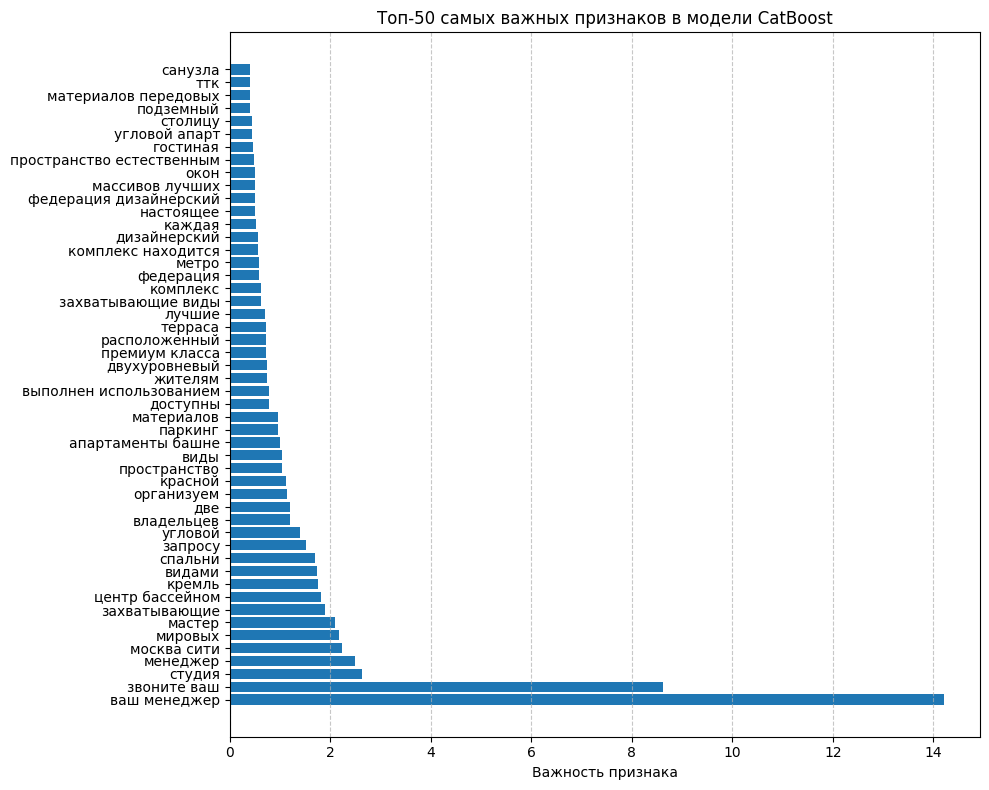

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Получаем важность признаков и названия фич
feature_importance = model.get_feature_importance()
feature_names = vectorizer.get_feature_names_out()  # или model.feature_names_, если есть

# 2. Объединяем в массив (важность + имя) и сортируем по важности (убывание)
sorted_idx = np.argsort(feature_importance)[::-1]  # индексы от большего к меньшему
top_idx = sorted_idx[:50]  # берём топ‑50


top_importance = feature_importance[top_idx]
top_names = feature_names[top_idx]

# 3. Рисуем график
plt.figure(figsize=(10, 8))
plt.barh(top_names, top_importance)
plt.xlabel('Важность признака')
plt.title('Топ‑50 самых важных признаков в модели CatBoost')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Довольно неожиданные результаты, но можно объяснить их важность более высокими ценами на недвижимость от риелторов и более качественные описания в таких объявлениях.
В целом даже в таком простом варианте модели описания объявлений могут значительно повысить качество предсказаний цен на недвижимость в совокупности с другими параметрами вроде площади, локации, этажа и др. 